In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

from ewatercycle.models import Wflow
from ewatercycle.parameter_sets import available_parameter_sets
from ewatercycle.forcing import sources

In [3]:
parameter_sets = available_parameter_sets(target_model="wflow")

print(parameter_sets.keys())


dict_keys(['wflow_rhine_sbm_nc', 'wflow_Rhine_ERA5-calibrated', 'wflow_Great-Kei_ERA5-calibrated', 'wflow_Doring_ERA5-calibrated', 'wflow_Merrimack_ERA5-calibrated', 'wflow_Meuse_ERA5-calibrated', 'wflow_rhine_ERA_Interim-calibrated', 'wflow_Savannah_ERA-Interim-calibrated', 'wflow_Great-Kei_ERA_Interim-calibrated', 'wflow_Merrimack_ERA_Interim-calibrated', 'wflow_Meuse_ERA_Interim-calibrated', 'wflow_merrimack_techpaper'])


In [4]:
parameter_set = parameter_sets["wflow_rhine_sbm_nc"]

print(parameter_set)
print("Directory:", parameter_set.directory)
print("Config:", parameter_set.config)

Parameter set
-------------
name=wflow_rhine_sbm_nc
directory=/data/shared/parameter-sets/wflow_rhine_sbm_nc
config=/data/shared/parameter-sets/wflow_rhine_sbm_nc/wflow_sbm_NC.ini
doi=N/A
target_model=wflow
supported_model_versions={'2020.1.3', '2020.1.1', '2020.1.2'}
downloader=None
Directory: /data/shared/parameter-sets/wflow_rhine_sbm_nc
Config: /data/shared/parameter-sets/wflow_rhine_sbm_nc/wflow_sbm_NC.ini


In [5]:
parameter_set.config = Path(parameter_set.directory) / "wflow_sbm_NC.ini"

print("Config bestand:", parameter_set.config)
print("Bestaat:", parameter_set.config.exists())

Config bestand: /data/shared/parameter-sets/wflow_rhine_sbm_nc/wflow_sbm_NC.ini
Bestaat: True


In [6]:
shape_file = Path("/home/niels/BEP-Niels/Rhine/Rhine.shp")

dem_file = Path(
    "/home/niels/BEP-Niels/Troepnotebooks/"
    "wflow_20260515_085409/staticmaps/wflow_dem.map"
)

print("Shape bestaat:", shape_file.exists())
print("DEM bestaat:", dem_file.exists())

if dem_file.exists():
    print("DEM grootte MB:", dem_file.stat().st_size / 1_000_000)

Shape bestaat: True
DEM bestaat: True
DEM grootte MB: 0.126668


In [7]:
start_time = "2004-01-01T00:00:00Z"
end_time = "2011-01-01T00:00:00Z"

forcing_directory = "wflow_forcing_ERA5_2004_2010_with_correct_dem"

print("Start:", start_time)
print("End:", end_time)
print("Directory:", forcing_directory)

Start: 2004-01-01T00:00:00Z
End: 2011-01-01T00:00:00Z
Directory: wflow_forcing_ERA5_2004_2010_with_correct_dem


In [8]:
WflowForcing = sources["WflowForcing"]

forcing = WflowForcing.generate(
    dataset="ERA5",
    start_time=start_time,
    end_time=end_time,
    shape=str(shape_file),
    dem_file=str(dem_file),
    directory=forcing_directory,
)

print(forcing)
print("Forcing directory:", forcing.directory)
print("NetCDF input:", forcing.netcdfinput)

start_time='2004-01-01T00:00:00Z' end_time='2011-01-01T00:00:00Z' directory=PosixPath('/home/niels/BEP-Niels/Troepnotebooks/wflow_forcing_ERA5_2004_2010_with_correct_dem/work/diagnostic/script') shape=PosixPath('/home/niels/BEP-Niels/Rhine/Rhine.shp') filenames={} netcdfinput='wflow_ERA5_Rhine_2004_2011.nc' Precipitation='/pr' EvapoTranspiration='/pet' Temperature='/tas' Inflow=None
Forcing directory: /home/niels/BEP-Niels/Troepnotebooks/wflow_forcing_ERA5_2004_2010_with_correct_dem/work/diagnostic/script
NetCDF input: wflow_ERA5_Rhine_2004_2011.nc


In [9]:
forcing_file = Path(forcing.directory) / forcing.netcdfinput

print("Forcingbestand:", forcing_file)
print("Bestaat:", forcing_file.exists())

Forcingbestand: /home/niels/BEP-Niels/Troepnotebooks/wflow_forcing_ERA5_2004_2010_with_correct_dem/work/diagnostic/script/wflow_ERA5_Rhine_2004_2011.nc
Bestaat: True


In [10]:
forcing_ds = xr.open_dataset(forcing_file)

print(forcing_ds)

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 2922, lat: 169, lon: 187, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 23kB 2004-01-01T12:00:00 ... 2011-12-31T...
  * lat        (lat) float64 1kB 52.05 52.02 51.98 51.94 ... 45.97 45.93 45.89
  * lon        (lon) float64 1kB 5.227 5.264 5.3 5.337 ... 11.97 12.01 12.05
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    pr         (time, lat, lon) float32 369MB ...
    time_bnds  (time, bnds) datetime64[ns] 47kB ...
    lat_bnds   (lat, bnds) float64 3kB ...
    lon_bnds   (lon, bnds) float64 3kB ...
    tas        (time, lat, lon) float32 369MB ...
    pet        (time, lat, lon) float32 369MB ...
Attributes:
    Conventions:  CF-1.7
    software:     Created with ESMValTool v2.11.1
    caption:      Forcings for the wflow hydrological model.


In [11]:
try:
    model.finalize()
except:
    pass

model = Wflow(
    parameter_set=parameter_set,
    forcing=forcing
)

cfg_file, cfg_dir = model.setup()
model.initialize(cfg_file)

print("Config file:", cfg_file)
print("Config directory:", cfg_dir)
print("Start time:", model.start_time)
print("End time:", model.end_time)
print("Current time:", model.time)
print("Output variables:", model.output_var_names)

Config file: /home/niels/BEP-Niels/Troepnotebooks/wflow_20260515_101202/wflow_ewatercycle.ini
Config directory: /home/niels/BEP-Niels/Troepnotebooks/wflow_20260515_101202
Start time: 1072915200.0
End time: 1293840000.0
Current time: 1072828800.0
Output variables: ('RiverRunoff',)


In [12]:
lat_lobith_model = 51.90
lon_lobith_model = 5.72

print("Lobith modelcel:")
print("Latitude:", lat_lobith_model)
print("Longitude:", lon_lobith_model)

Lobith modelcel:
Latitude: 51.9
Longitude: 5.72


In [13]:
for i in range(20):
    model.update()
    
    q_lobith = model.get_value_at_coords(
        "RiverRunoff",
        lat=[lat_lobith_model],
        lon=[lon_lobith_model]
    )[0]
    
    runoff_grid = model.get_value("RiverRunoff")
    
    print(
        i + 1,
        model.time_as_datetime,
        "Lobith:", q_lobith,
        "Grid max:", np.nanmax(runoff_grid)
    )

1 2004-01-01 00:00:00 Lobith: 0.00052810344 Grid max: 0.06034842
2 2004-01-02 00:00:00 Lobith: 0.00036990663 Grid max: 0.19398525
3 2004-01-03 00:00:00 Lobith: 0.0002608117 Grid max: 0.25614053
4 2004-01-04 00:00:00 Lobith: 0.0011236826 Grid max: 0.30264494
5 2004-01-05 00:00:00 Lobith: 0.0012451436 Grid max: 0.35211083
6 2004-01-06 00:00:00 Lobith: 0.0077718296 Grid max: 0.37728637
7 2004-01-07 00:00:00 Lobith: 0.0070296344 Grid max: 0.4210462
8 2004-01-08 00:00:00 Lobith: 0.01222693 Grid max: 0.48517668
9 2004-01-09 00:00:00 Lobith: 0.01702308 Grid max: 0.9609109
10 2004-01-10 00:00:00 Lobith: 0.01737057 Grid max: 1.6714096
11 2004-01-11 00:00:00 Lobith: 0.06474652 Grid max: 9.4083805
12 2004-01-12 00:00:00 Lobith: 0.09378722 Grid max: 229.63734
13 2004-01-13 00:00:00 Lobith: 0.16149747 Grid max: 1770.3287
14 2004-01-14 00:00:00 Lobith: 0.2694746 Grid max: 2912.734
15 2004-01-15 00:00:00 Lobith: 0.3250514 Grid max: 3407.6228
16 2004-01-16 00:00:00 Lobith: 0.51636034 Grid max: 3458.60

In [14]:
try:
    model.finalize()
except:
    pass

model = Wflow(
    parameter_set=parameter_set,
    forcing=forcing
)

cfg_file, cfg_dir = model.setup()
model.initialize(cfg_file)

print("Model opnieuw gestart")
print("Start time:", model.start_time)
print("End time:", model.end_time)

Model opnieuw gestart
Start time: 1072915200.0
End time: 1293840000.0


In [15]:
Q_model = []
time_model = []

while model.time < model.end_time:
    model.update()
    
    q_lobith = model.get_value_at_coords(
        "RiverRunoff",
        lat=[lat_lobith_model],
        lon=[lon_lobith_model]
    )[0]
    
    Q_model.append(float(q_lobith))
    time_model.append(model.time_as_datetime)

model_output = pd.DataFrame({
    "date": pd.to_datetime(time_model),
    "Q_model_m3s": Q_model
})

print("Aantal modelstappen:", len(model_output))
print("Eerste datum:", model_output["date"].min())
print("Laatste datum:", model_output["date"].max())

model_output.head()

Aantal modelstappen: 2558
Eerste datum: 2004-01-01 00:00:00
Laatste datum: 2011-01-01 00:00:00


,date,Q_model_m3s
0,2004-01-01,0.000528
1,2004-01-02,0.000370
2,2004-01-03,0.000261
3,2004-01-04,0.001124
4,2004-01-05,0.001245


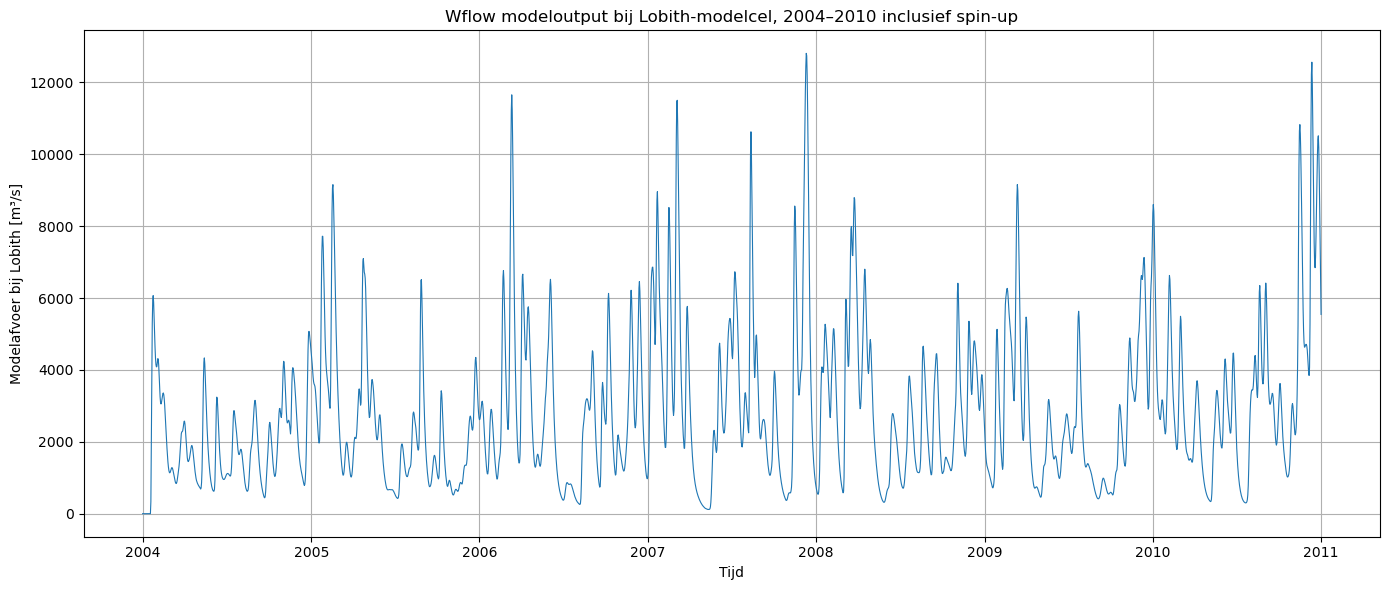

In [16]:
plt.figure(figsize=(14, 6))

plt.plot(
    model_output["date"],
    model_output["Q_model_m3s"],
    linewidth=0.8
)

plt.xlabel("Tijd")
plt.ylabel("Modelafvoer bij Lobith [m³/s]")
plt.title("Wflow modeloutput bij Lobith-modelcel, 2004–2010 inclusief spin-up")
plt.grid(True)

plt.tight_layout()
plt.show()

In [23]:
model_output_validation = model_output[
    (model_output["date"] >= "2005-01-01") &
    (model_output["date"] <= "2010-12-31")
].copy()

print("Aantal validatiedagen:", len(model_output_validation))
print("Eerste validatiedatum:", model_output_validation["date"].min())
print("Laatste validatiedatum:", model_output_validation["date"].max())

model_output_validation.head()

Aantal validatiedagen: 2191
Eerste validatiedatum: 2005-01-01 00:00:00
Laatste validatiedatum: 2010-12-31 00:00:00


,date,Q_model_m3s
366,2005-01-01,4478.155762
367,2005-01-02,4328.943359
368,2005-01-03,4163.805176
369,2005-01-04,3979.241455
370,2005-01-05,3801.807129


In [24]:
expected_validation_days = len(pd.date_range("2005-01-01", "2010-12-31", freq="D"))

print("Verwacht aantal validatiedagen:", expected_validation_days)

Verwacht aantal validatiedagen: 2191


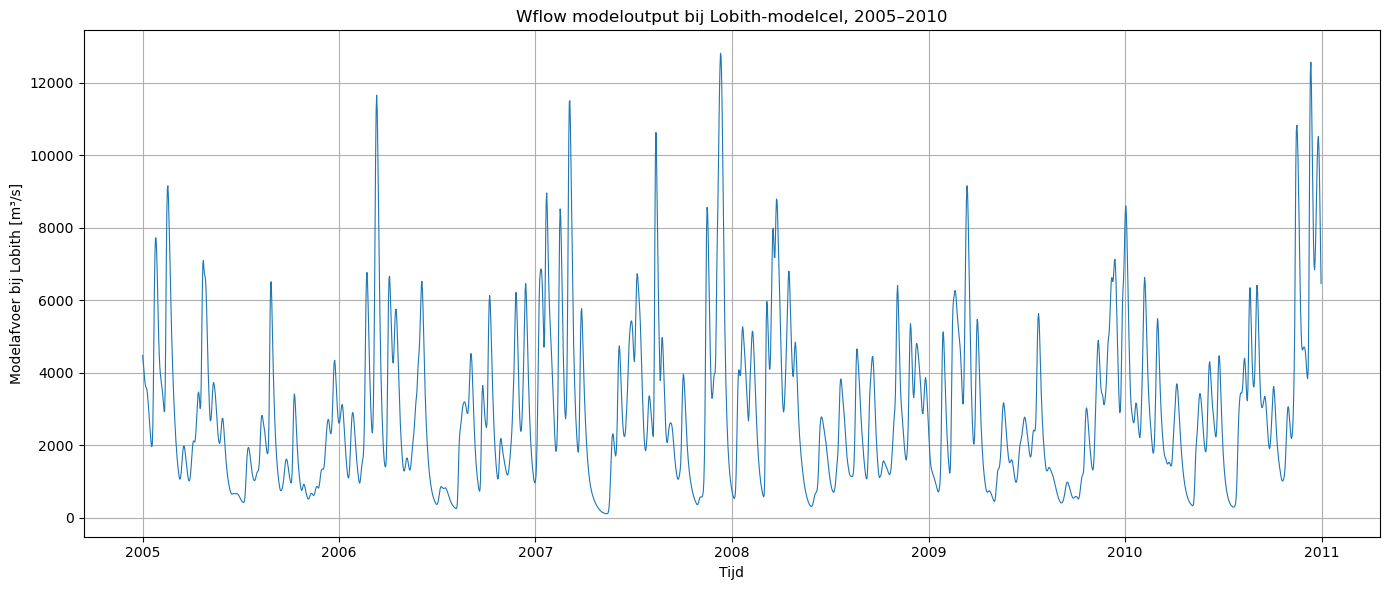

In [25]:
plt.figure(figsize=(14, 6))

plt.plot(
    model_output_validation["date"],
    model_output_validation["Q_model_m3s"],
    linewidth=0.8
)

plt.xlabel("Tijd")
plt.ylabel("Modelafvoer bij Lobith [m³/s]")
plt.title("Wflow modeloutput bij Lobith-modelcel, 2005–2010")
plt.grid(True)

plt.tight_layout()
plt.show()

In [26]:
output_file = Path("/home/niels/BEP-Niels/model_output_lobith_2005_2010_daily.xlsx")

model_output_validation.to_excel(output_file, index=False)

print("Opgeslagen als:", output_file)

Opgeslagen als: /home/niels/BEP-Niels/model_output_lobith_2005_2010_daily.xlsx


In [17]:
obs_file = Path("/home/niels/BEP-Niels/Data Lobith/Lobith_daggemiddelden.xlsx")

observed_daily = pd.read_excel(obs_file)

observed_daily.head()

,date,Q_mean_m3s
0,1950-01-01,1425.0
1,1950-01-02,1360.0
2,1950-01-03,1330.0
3,1950-01-04,1320.0
4,1950-01-05,1330.0


In [18]:
observed_daily["date"] = pd.to_datetime(observed_daily["date"])

In [19]:
observed_daily = observed_daily.rename(columns={"datetime": "date"})
observed_daily["date"] = pd.to_datetime(observed_daily["date"])

In [20]:
observed_selection = observed_daily[
    (observed_daily["date"] >= "2005-01-01") &
    (observed_daily["date"] <= "2010-12-31")
].copy()

print("Aantal meetdagen:", len(observed_selection))
print("Eerste datum:", observed_selection["date"].min())
print("Laatste datum:", observed_selection["date"].max())

observed_selection.head()

Aantal meetdagen: 2191
Eerste datum: 2005-01-01 00:00:00
Laatste datum: 2010-12-31 00:00:00


,date,Q_mean_m3s
17236,2005-01-01,2198.041667
17237,2005-01-02,2084.208333
17238,2005-01-03,2039.416667
17239,2005-01-04,2041.000000
17240,2005-01-05,2085.541667


In [27]:
comparison = pd.merge(
    observed_selection,
    model_output_validation,
    on="date",
    how="inner"
)

print("Aantal overlappende dagen:", len(comparison))
print("Eerste overlappende datum:", comparison["date"].min())
print("Laatste overlappende datum:", comparison["date"].max())

comparison.head()

Aantal overlappende dagen: 2191
Eerste overlappende datum: 2005-01-01 00:00:00
Laatste overlappende datum: 2010-12-31 00:00:00


,date,Q_mean_m3s,Q_model_m3s
0,2005-01-01,2198.041667,4478.155762
1,2005-01-02,2084.208333,4328.943359
2,2005-01-03,2039.416667,4163.805176
3,2005-01-04,2041.000000,3979.241455
4,2005-01-05,2085.541667,3801.807129


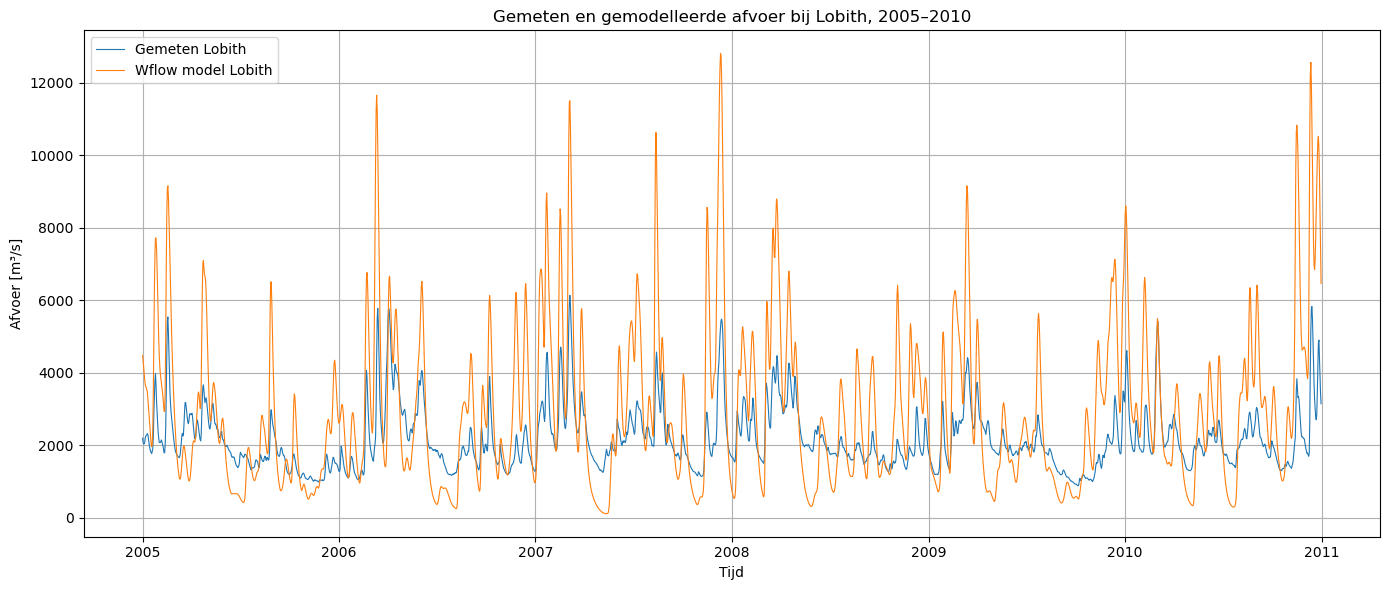

In [28]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison["date"],
    comparison["Q_mean_m3s"],
    label="Gemeten Lobith",
    linewidth=0.8
)

plt.plot(
    comparison["date"],
    comparison["Q_model_m3s"],
    label="Wflow model Lobith",
    linewidth=0.8
)

plt.xlabel("Tijd")
plt.ylabel("Afvoer [m³/s]")
plt.title("Gemeten en gemodelleerde afvoer bij Lobith, 2005–2010")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [29]:
obs = comparison["Q_mean_m3s"]
sim = comparison["Q_model_m3s"]

rmse = np.sqrt(((sim - obs) ** 2).mean())
bias = sim.mean() - obs.mean()
correlation = obs.corr(sim)

print("RMSE:", rmse)
print("Bias:", bias)
print("Correlatie:", correlation)

RMSE: 1790.8730714693356
Bias: 797.7560808003882
Correlatie: 0.7918415491387085


In [30]:
calib_data = comparison.copy()

calib_data = calib_data.dropna(subset=["Q_mean_m3s", "Q_model_m3s"])

obs = calib_data["Q_mean_m3s"]
sim = calib_data["Q_model_m3s"]

calib_data.head()

,date,Q_mean_m3s,Q_model_m3s
0,2005-01-01,2198.041667,4478.155762
1,2005-01-02,2084.208333,4328.943359
2,2005-01-03,2039.416667,4163.805176
3,2005-01-04,2041.000000,3979.241455
4,2005-01-05,2085.541667,3801.807129


In [31]:
rmse_original = np.sqrt(((sim - obs) ** 2).mean())
bias_original = sim.mean() - obs.mean()
corr_original = obs.corr(sim)

print("Origineel model")
print("RMSE:", rmse_original)
print("Bias:", bias_original)
print("Correlatie:", corr_original)
print("Gemiddelde meting:", obs.mean())
print("Gemiddelde model:", sim.mean())

Origineel model
RMSE: 1790.8730714693356
Bias: 797.7560808003882
Correlatie: 0.7918415491387085
Gemiddelde meting: 2174.954263654344
Gemiddelde model: 2972.710344454732


In [32]:
low_flow_limit = 2000

low_flow_data = calib_data[
    calib_data["Q_mean_m3s"] < low_flow_limit
].copy()

print("Aantal laagwaterdagen in kalibratie:", len(low_flow_data))

Aantal laagwaterdagen in kalibratie: 1155


In [33]:
a_low, b_low = np.polyfit(
    low_flow_data["Q_model_m3s"],
    low_flow_data["Q_mean_m3s"],
    1
)

print("a_low:", a_low)
print("b_low:", b_low)

a_low: 0.10175690704075954
b_low: 1410.8686473385449


In [34]:
calib_data["Q_model_lowflowfit_m3s"] = (
    a_low * calib_data["Q_model_m3s"] + b_low
)

calib_data["Q_model_lowflowfit_m3s"] = calib_data["Q_model_lowflowfit_m3s"].clip(lower=0)

In [35]:
sim_lowfit = calib_data["Q_model_lowflowfit_m3s"]

rmse_lowfit = np.sqrt(((sim_lowfit - obs) ** 2).mean())
bias_lowfit = sim_lowfit.mean() - obs.mean()
corr_lowfit = obs.corr(sim_lowfit)

print("Laagwatergerichte kalibratie, prestatie op alle dagen")
print("RMSE:", rmse_lowfit)
print("Bias:", bias_lowfit)
print("Correlatie:", corr_lowfit)

Laagwatergerichte kalibratie, prestatie op alle dagen
RMSE: 829.8176482978904
Bias: -461.5918061360144
Correlatie: 0.7918415491387086


In [36]:
low_check = calib_data[
    calib_data["Q_mean_m3s"] < low_flow_limit
].copy()

obs_low = low_check["Q_mean_m3s"]
sim_low_original = low_check["Q_model_m3s"]
sim_low_calibrated = low_check["Q_model_lowflowfit_m3s"]

rmse_low_original = np.sqrt(((sim_low_original - obs_low) ** 2).mean())
rmse_low_calibrated = np.sqrt(((sim_low_calibrated - obs_low) ** 2).mean())

bias_low_original = sim_low_original.mean() - obs_low.mean()
bias_low_calibrated = sim_low_calibrated.mean() - obs_low.mean()

print("Alleen laagwaterdagen")
print("Originele RMSE:", rmse_low_original)
print("Gekalibreerde RMSE:", rmse_low_calibrated)
print("Originele bias:", bias_low_original)
print("Gekalibreerde bias:", bias_low_calibrated)

Alleen laagwaterdagen
Originele RMSE: 1030.3796681882666
Gekalibreerde RMSE: 256.7453901785215
Originele bias: 130.0516905813506
Gekalibreerde bias: 0.0


In [1]:
plt.figure(figsize=(14, 6))

plt.plot(
    calib_data["date"],
    calib_data["Q_mean_m3s"],
    label="Gemeten Lobith",
    linewidth=0.8
)

plt.plot(
    calib_data["date"],
    calib_data["Q_model_m3s"],
    label="Wflow origineel",
    linewidth=0.7,
    alpha=0.7
)

plt.plot(
    calib_data["date"],
    calib_data["Q_model_lowflowfit_m3s"],
    label="Wflow gekalibreerd op laagwater",
    linewidth=0.8
)

plt.xlabel("Tijd")
plt.ylabel("Afvoer [m³/s]")
plt.title("Gemeten en gekalibreerde wflow-afvoer bij Lobith, 2005–2010")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [40]:
factor = obs.mean() / sim.mean()

calib_data["Q_model_factor_m3s"] = calib_data["Q_model_m3s"] * factor

print("Schaalfactor:", factor)

Schaalfactor: 0.7316401571755837


In [41]:
sim_factor = calib_data["Q_model_factor_m3s"]

rmse_factor = np.sqrt(((sim_factor - obs) ** 2).mean())
bias_factor = sim_factor.mean() - obs.mean()
corr_factor = obs.corr(sim_factor)

print("Na schaalfactor")
print("RMSE:", rmse_factor)
print("Bias:", bias_factor)
print("Correlatie:", corr_factor)

Na schaalfactor
RMSE: 1064.395200160694
Bias: 4.547473508864641e-13
Correlatie: 0.7918415491387091


In [42]:
a, b = np.polyfit(
    calib_data["Q_model_m3s"],
    calib_data["Q_mean_m3s"],
    1
)

print("a:", a)
print("b:", b)

a: 0.30804936335155964
b: 1259.2127346164684


In [43]:
calib_data["Q_model_linear_m3s"] = (
    a * calib_data["Q_model_m3s"] + b
)

calib_data["Q_model_linear_m3s"] = calib_data["Q_model_linear_m3s"].clip(lower=0)

In [44]:
sim_linear = calib_data["Q_model_linear_m3s"]

rmse_linear = np.sqrt(((sim_linear - obs) ** 2).mean())
bias_linear = sim_linear.mean() - obs.mean()
corr_linear = obs.corr(sim_linear)

print("Na lineaire kalibratie")
print("RMSE:", rmse_linear)
print("Bias:", bias_linear)
print("Correlatie:", corr_linear)

Na lineaire kalibratie
RMSE: 520.700172331775
Bias: 4.547473508864641e-13
Correlatie: 0.7918415491387085


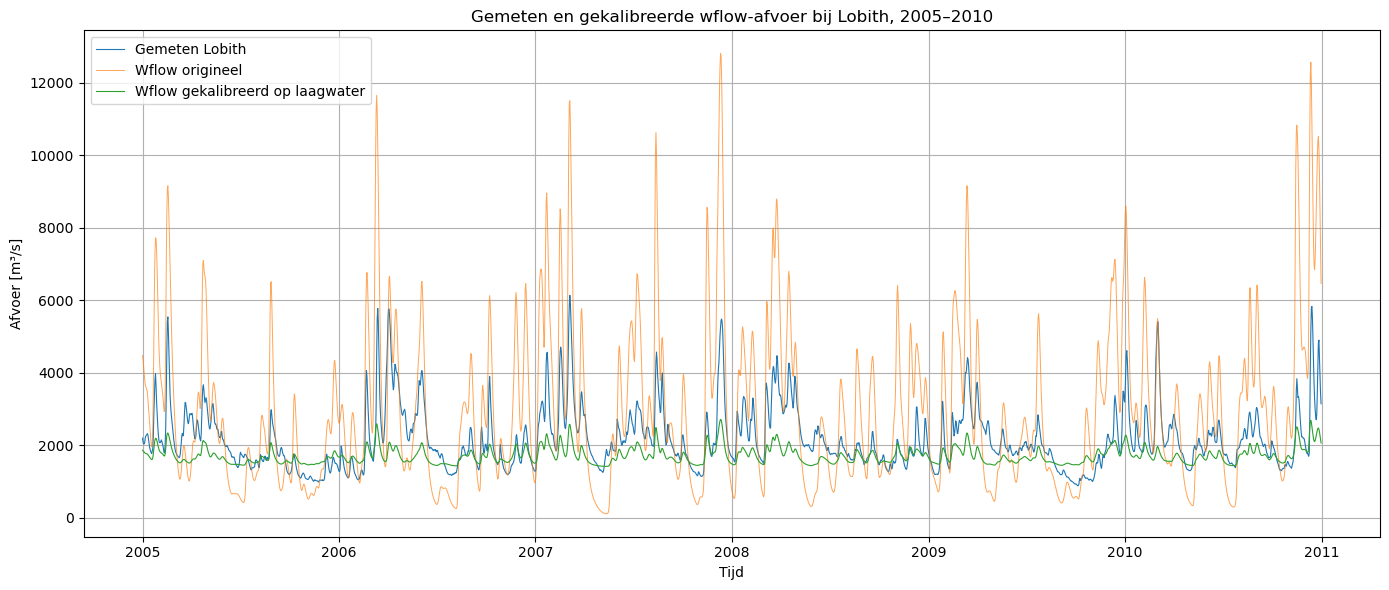

In [45]:
plt.figure(figsize=(14, 6))

plt.plot(
    calib_data["date"],
    calib_data["Q_mean_m3s"],
    label="Gemeten Lobith",
    linewidth=0.8
)

plt.plot(
    calib_data["date"],
    calib_data["Q_model_m3s"],
    label="Wflow origineel",
    linewidth=0.7,
    alpha=0.7
)

plt.plot(
    calib_data["date"],
    calib_data["Q_model_lowflowfit_m3s"],
    label="Wflow gekalibreerd op laagwater",
    linewidth=0.8
)

plt.xlabel("Tijd")
plt.ylabel("Afvoer [m³/s]")
plt.title("Gemeten en gekalibreerde wflow-afvoer bij Lobith, 2005–2010")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [46]:
output_file = Path("/home/niels/BEP-Niels/model_output_lobith_2005_2010_daily.xlsx")

model_output_validation.to_excel(output_file, index=False)

print("Opgeslagen als:", output_file)

Opgeslagen als: /home/niels/BEP-Niels/model_output_lobith_2005_2010_daily.xlsx
